# 4-qubit block reduction

In this code we test the idea of "replacement" of the the block (full block)

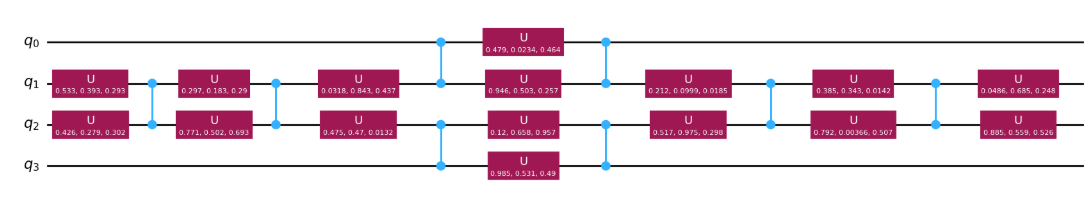

with the block (reduced block)

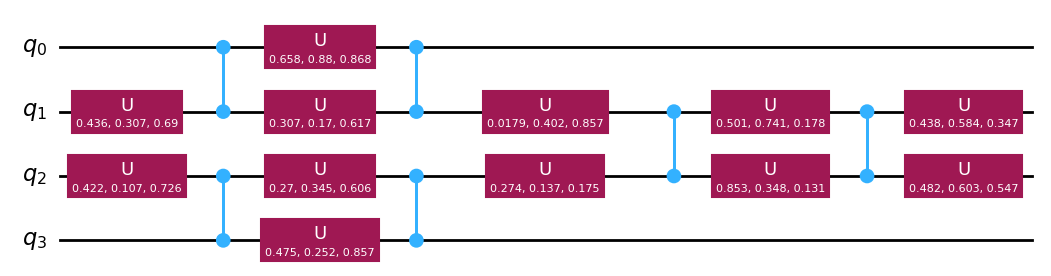

Replacement means that we find the reduced block that has the approximately the same operator as the full block.

To find the reduced block we use optimization procedure, where we optimize U3-gates agles of the reduced block to fit the initial full block.

We used standard deviation of each element of a matrix of the reduced block from the elements of the initial full block matrix as a measure of precision.

## Some conclusions
1) Typical value of standard deviation of each elemet in the 16 x 16 matrix between full and reduced block is about 0.003. Note that the maximum value of any element is below 1.
2) The optimization goes better (higher precision is obtained) if the angles of the U-gates in the initial full block are smaller.

In [2]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from qiskit.visualization import circuit_drawer

from IPython.display import display

import numpy as np
import random
import copy
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

### Define all the functions for creating and optimizing the blocks

In [3]:
# Here we define function creating circuits (and operators) shown abvove
# We also define functions performin optimization
def block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)
    
    q_2.cz(0,1)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(2,3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    return q_2

def block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)
    
    q_2.cz(0,1)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(2,3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    op = Operator(q_2)
    return op

def reduced_block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)

    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)
    q_2.cz(2,3)
    
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    
    q_2.cz(1,2)
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.cz(1,2)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    
    return q_2

def reduced_block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)
    q_2.cz(2,3)
    
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    
    q_2.cz(1,2)
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.cz(1,2)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    op = Operator(q_2)
    return op

def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el

def estim_func(params, init_circ):
    test_circ = reduced_block_4(params)
    est = double_q_diff(init_circ, test_circ)
    return est

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],

}
def find_alt_params(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_4(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(36) * 2 * PI
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        res = minimize(
                    estim_func,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

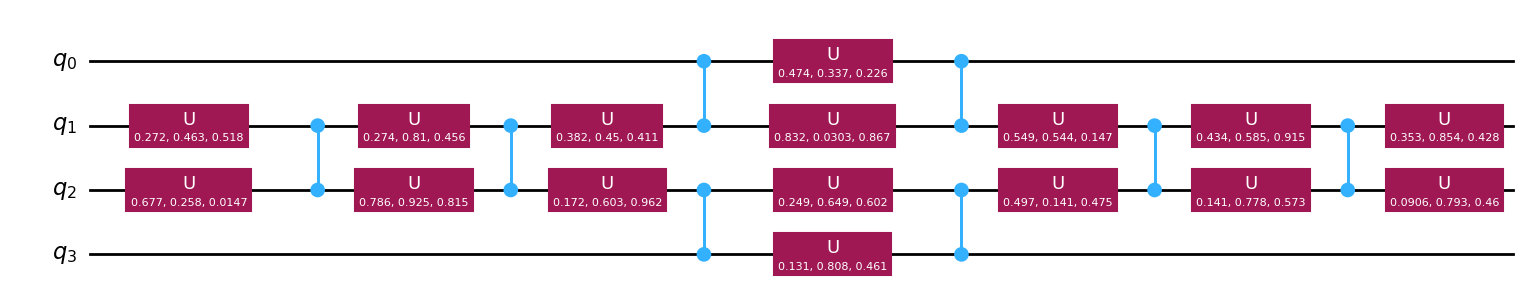

In [4]:
# Show the initial full block obtained with the functions from the previous section
random_array = np.random.rand(48) #the block is defined by 48 angles in the U-gates
qc = block_4_circ(random_array)
qc.draw('mpl')

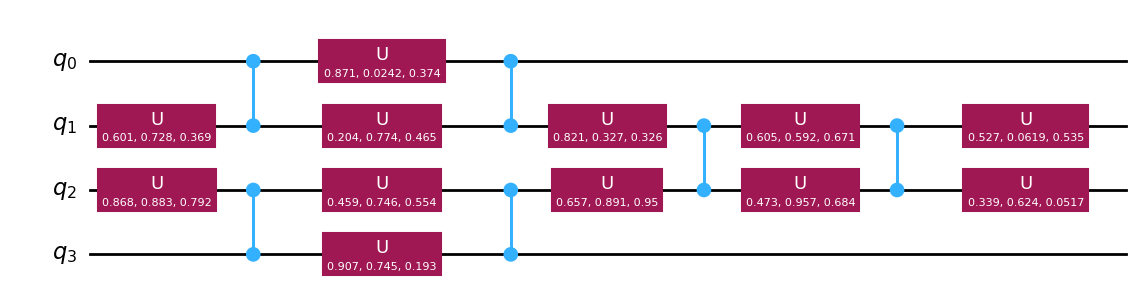

In [5]:
# Show the reduced block obtained with the functions from the previous section
random_array = np.random.rand(36) #the block is defined by 48 angles in the U-gates
qc = reduced_block_4_circ(random_array)
qc.draw('mpl')

### Test optimization procedure

In [6]:
# Here we just define some random parameters for the intial block
params_init = np.random.rand(48) * 2 * PI
#params_init

In [7]:
# Create a full block with params_init and find parameters of the reduced block (new_params) using optimization
start_time = time.time()
new_params = [] # parametes of the reduced block
block_devs = [] # deviation of the reduced block from the initial full block
n_tries = 3 #number of optimization tries
prec = 0.005 #desired precision (may not be achieved in some cases)
for i in range(1): #
    res_min = find_alt_params(params_init, prec, n_tries)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
  
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

Elapsed time: 29.264880895614624 seconds


In [100]:
# Check the deviation of the reduced block from the initial full block
# deviation is just standard deviation of elements in the matrix describing the reduced block from the elements in the full block matrix
# see function double_q_diff(mat_1, mat_2): for more details
block_devs

[0.003988664642586637]

In [442]:
#Create circuits for full and reduced blocks
qc_init = block_4_circ(params_init)
qc_init.measure_all()
qc_red = reduced_block_4_circ(new_params[0])
qc_red.measure_all()

In [443]:
# performing simulations of the full block
simulator = AerSimulator()
qc_merged_t = transpile(qc_init, simulator)
result = simulator.run(qc_merged_t,shots = 1000).result()
counts_init = result.get_counts(qc_merged_t)

In [444]:
# performing simulations of the reduced block
qc_merged_t = transpile(qc_red, simulator)
result = simulator.run(qc_merged_t,shots = 1000).result()
counts_red = result.get_counts(qc_merged_t)

In [445]:
# Comparing counts for full and reduced blocks
print(sorted(counts_init.items(), key=lambda item: item[1], reverse=True) )
print(sorted(counts_red.items(), key=lambda item: item[1], reverse=True) )

[('1010', 334), ('1101', 162), ('1011', 141), ('1001', 128), ('1000', 95), ('1100', 54), ('1110', 34), ('1111', 28), ('0100', 8), ('0011', 8), ('0001', 3), ('0000', 2), ('0101', 1), ('0010', 1), ('0111', 1)]
[('1010', 357), ('1101', 230), ('1011', 137), ('1110', 103), ('1100', 64), ('1001', 62), ('1111', 28), ('1000', 16), ('0010', 1), ('0111', 1), ('0100', 1)]


In [446]:
# Showing matrices of full and reduced blocks
matr_init = block_4(params_init)
matr_red = reduced_block_4(new_params[0])
#matr_init - matr_red

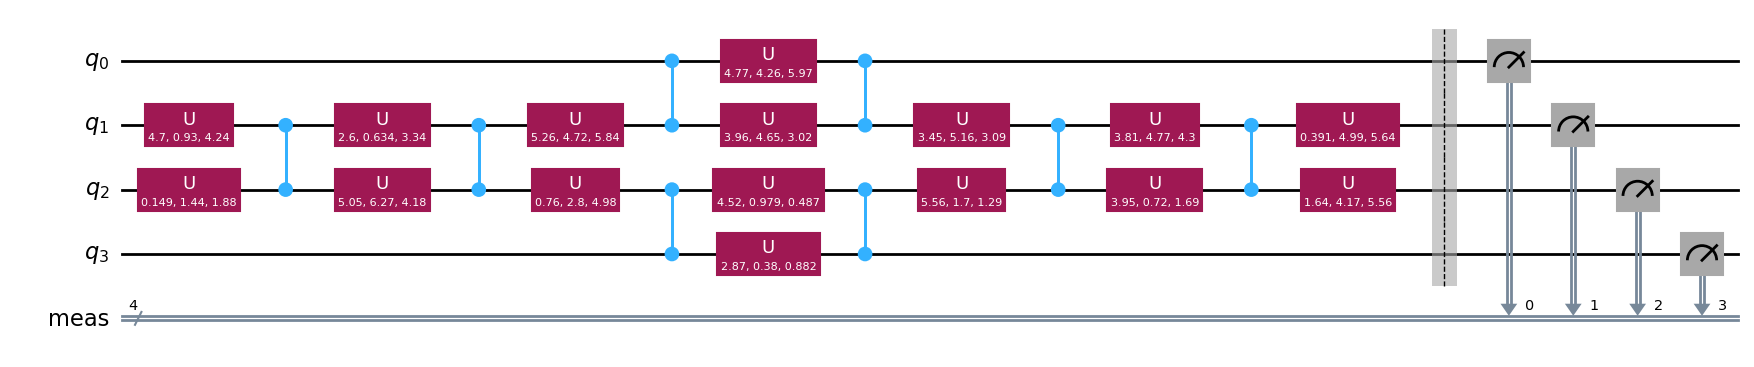

In [447]:
# Showing the initial full block
qc_init.draw('mpl')

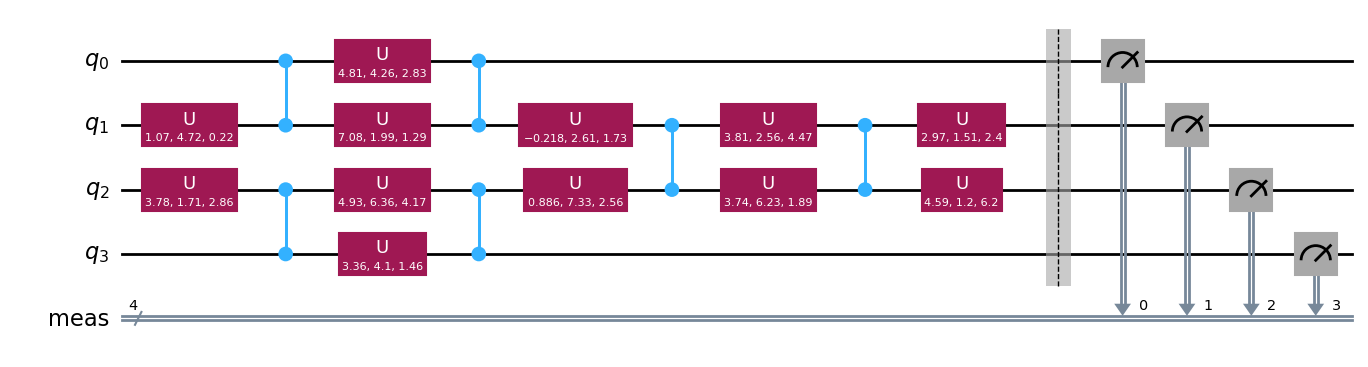

In [449]:
# Showing the reduced block approximately equivalent to the initial block
qc_red.draw('mpl')

### Plot and save figures for the paper

In [9]:
# Draw the circuit using the matplotlib backend
fig = circuit_drawer(qc_init, output='mpl')

# Add a text annotation to the figure
#fig.text(0.5, 0.90, "(a)", ha='center', fontsize=14)

# Save or show
fig.savefig("fig_circuit_red_a.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

# Draw the circuit using the matplotlib backend
fig_mer = circuit_drawer(qc_red, output='mpl')

# Add a text annotation to the figure
#fig_mer.text(0.5, 0.90, "(b)", ha='center', fontsize=14)

# Save or show
fig_mer.savefig("fig_circuit_red_b.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

# Slightly modified 4-qubit blocks

Here we add 4 more u gates to the full and reduced blocks

Full block:
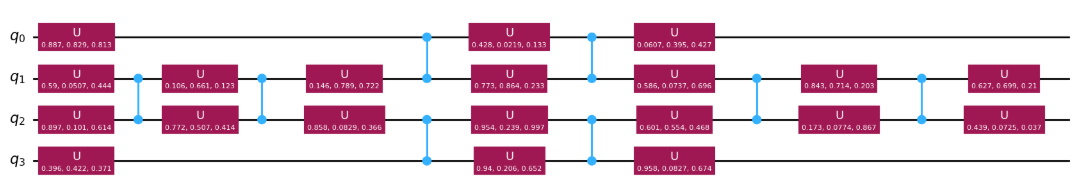

Reduced block:
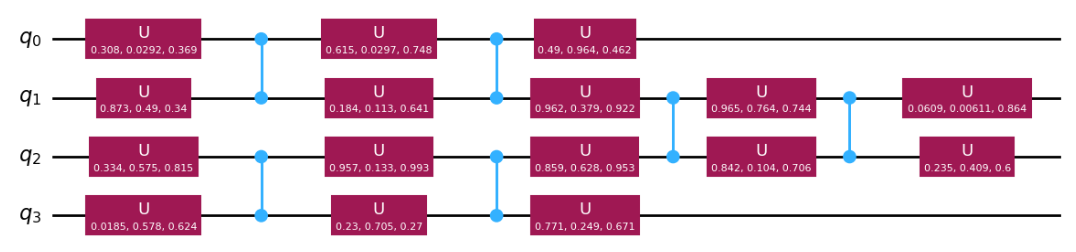

In [11]:
# define functions creating modified 4-qubit blocks
def block_4_circ_1(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)

    q_2.u(par[18], par[19], par[20], 0)
    q_2.cz(0,1)
    q_2.u(par[21], par[22], par[23], 0)
    q_2.u(par[24], par[25], par[26], 1)
    q_2.cz(0,1)
    q_2.u(par[27], par[28], par[29], 0)

    q_2.u(par[30], par[31], par[32], 3)
    q_2.cz(2,3)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.cz(2,3)
    q_2.u(par[39], par[40], par[41], 3)
    
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    q_2.cz(1,2)
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.cz(1,2)
    q_2.u(par[54], par[55], par[56], 1)
    q_2.u(par[57], par[58], par[59], 2)
    
    return q_2

def block_4_1(par):
    q_2 = qiskit.QuantumCircuit(4)
    
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)

    q_2.u(par[18], par[19], par[20], 0)
    q_2.cz(0,1)
    q_2.u(par[21], par[22], par[23], 0)
    q_2.u(par[24], par[25], par[26], 1)
    q_2.cz(0,1)
    q_2.u(par[27], par[28], par[29], 0)

    q_2.u(par[30], par[31], par[32], 3)
    q_2.cz(2,3)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.cz(2,3)
    q_2.u(par[39], par[40], par[41], 3)
    
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    q_2.cz(1,2)
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.cz(1,2)
    q_2.u(par[54], par[55], par[56], 1)
    q_2.u(par[57], par[58], par[59], 2)
    
    op = Operator(q_2)
    return op

def reduced_block_4_circ_1(par):
    q_2 = qiskit.QuantumCircuit(4)

    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)

    q_2.u(par[6], par[7], par[8], 0)
    q_2.cz(0,1)
    q_2.u(par[9], par[10], par[11], 0)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.cz(0,1)
    q_2.u(par[15], par[16], par[17], 0)

    q_2.u(par[18], par[19], par[20], 3)
    q_2.cz(2,3)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.cz(2,3)
    q_2.u(par[27], par[28], par[29], 3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    
    return q_2

def reduced_block_4_1(par):
    q_2 = qiskit.QuantumCircuit(4)

    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)

    q_2.u(par[6], par[7], par[8], 0)
    q_2.cz(0,1)
    q_2.u(par[9], par[10], par[11], 0)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.cz(0,1)
    q_2.u(par[15], par[16], par[17], 0)

    q_2.u(par[18], par[19], par[20], 3)
    q_2.cz(2,3)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.cz(2,3)
    q_2.u(par[27], par[28], par[29], 3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    
    op = Operator(q_2)
    return op


def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el

cost_history_dict = []
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

def estim_func_1(params, init_circ):
    #init_circ = block_4_1(params_init)
    test_circ = reduced_block_4_1(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    return est
    
def find_alt_params_1(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_4_1(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(48) * 0.5 * PI
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_1,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

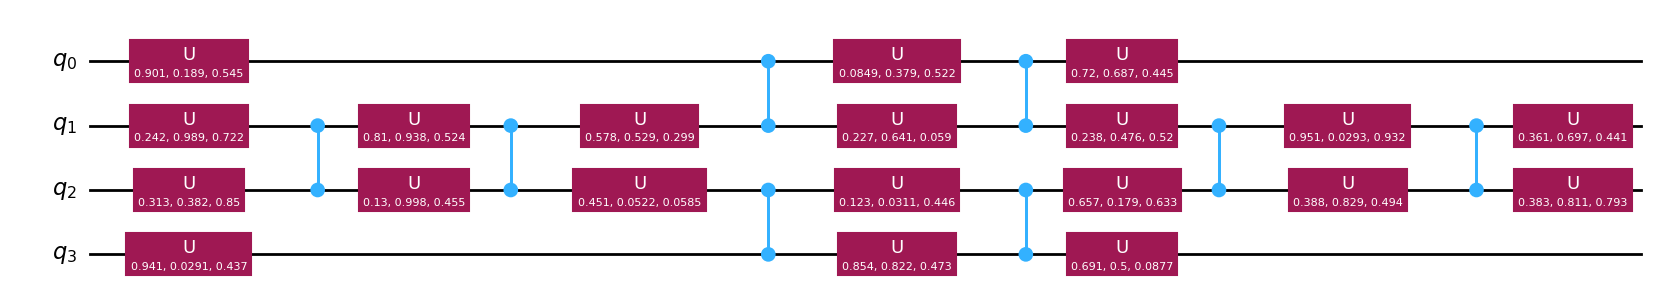

In [9]:
# Show a random initial full block
random_array = np.random.rand(60)
qc = block_4_circ_1(random_array)
qc.draw('mpl')

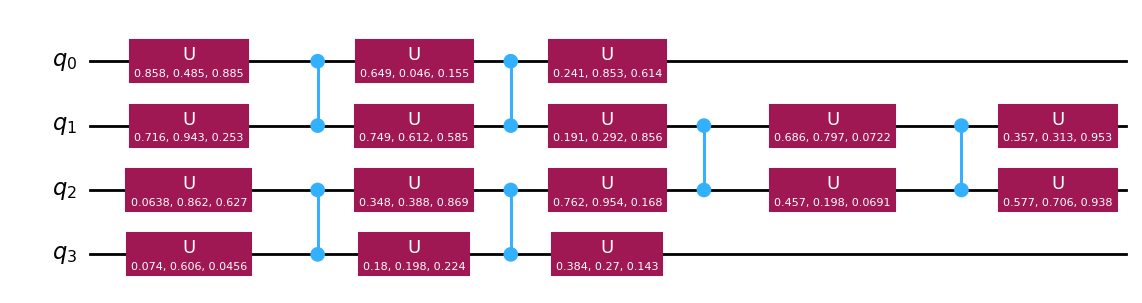

In [10]:
# Show a random reduced block
random_array = np.random.rand(48)
qc = reduced_block_4_circ_1(random_array)
qc.draw('mpl')

In [12]:
# create an initial full block and then find the reduced block using optimization
cost_history_dict = { # We keep history of the optimization to study various optimization functions and parameters
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
params_init = np.random.rand(60)* 2 * PI # create a random initial full block
start_time = time.time()
new_params = []
block_devs = []
prec = 0.005
n_tries = 2
for i in range(1):
    res_min = find_alt_params_1(params_init, prec, n_tries)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
print(new_params)

Elapsed time: 23.375935077667236 seconds
[array([ 2.77379898,  0.52728461,  2.58253528, -0.04848216,  1.6210449 ,
       -0.02992871,  2.63320749,  1.06868538,  0.61420194,  3.05180061,
        0.39603352,  0.80956578,  3.01398203, -0.68416969,  1.33308539,
        3.2906087 , -0.20492024, -0.06481246,  1.41293351,  1.50436798,
       -1.04098843,  0.74704569,  0.24062698,  2.34412214,  3.18403052,
        2.02205582,  2.37618639,  0.83460638,  1.32607545,  0.07310076,
        0.79349763,  0.38350805,  1.74971343,  1.35979337,  1.43632989,
        1.26040807,  1.73103313,  0.14655206,  1.4533658 ,  0.31275596,
        0.34346609,  0.41266945,  0.33241166,  2.05115922,  1.23659917,
        0.74406093,  1.95510567,  1.79367211])]


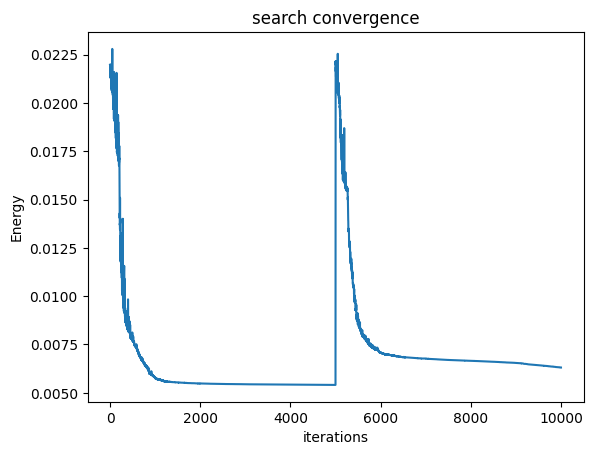

In [17]:
# Plot the cost function as a function of iteration number in the optimization procedure
en = cost_history_dict["cost_history"]
iterations = range(len(en))
# Create the plot
plt.plot(iterations, en)

# Add labels and title
plt.xlabel('iterations')
plt.ylabel('Energy')
plt.title('search convergence')

# Display the plot
plt.show()

#results.append(res)


## Option 4

In [272]:
def block_6_circ(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)
    q_2.cz(2,3)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.u(par[39], par[40], par[41], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[42], par[43], par[44], 0)
    q_2.u(par[45], par[46], par[47], 1)
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.u(par[54], par[55], par[56], 4)
    q_2.u(par[57], par[58], par[59], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[72], par[73], par[74], 1)
    q_2.u(par[75], par[76], par[77], 2)
    q_2.u(par[78], par[79], par[80], 3)
    q_2.u(par[81], par[82], par[83], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    q_2.cz(2,3)
    q_2.u(par[90], par[91], par[92], 2)
    q_2.u(par[93], par[94], par[95], 3)
    q_2.cz(2,3)
    q_2.u(par[96], par[97], par[98], 2)
    q_2.u(par[99], par[100], par[101], 3)
    
    return q_2

def block_6(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)
    q_2.cz(2,3)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.u(par[39], par[40], par[41], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[42], par[43], par[44], 0)
    q_2.u(par[45], par[46], par[47], 1)
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.u(par[54], par[55], par[56], 4)
    q_2.u(par[57], par[58], par[59], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[72], par[73], par[74], 1)
    q_2.u(par[75], par[76], par[77], 2)
    q_2.u(par[78], par[79], par[80], 3)
    q_2.u(par[81], par[82], par[83], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    q_2.cz(2,3)
    q_2.u(par[90], par[91], par[92], 2)
    q_2.u(par[93], par[94], par[95], 3)
    q_2.cz(2,3)
    q_2.u(par[96], par[97], par[98], 2)
    q_2.u(par[99], par[100], par[101], 3)
    
    op = Operator(q_2)
    return op

def reduced_block_6_circ(par):

    q_2 = qiskit.QuantumCircuit(6)
    
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.u(par[12], par[13], par[14], 3)
    q_2.u(par[15], par[16], par[17], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[30], par[31], par[32], 0)
    q_2.u(par[33], par[34], par[35], 1)
    q_2.u(par[36], par[37], par[38], 2)
    q_2.u(par[39], par[40], par[41], 3)
    q_2.u(par[42], par[43], par[44], 4)
    q_2.u(par[45], par[46], par[47], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    q_2.cz(2,3)
    q_2.u(par[78], par[79], par[80], 2)
    q_2.u(par[81], par[82], par[83], 3)
    q_2.cz(2,3)
    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    
    return q_2


def reduced_block_6(par):
    q_2 = qiskit.QuantumCircuit(6)

    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.u(par[12], par[13], par[14], 3)
    q_2.u(par[15], par[16], par[17], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[30], par[31], par[32], 0)
    q_2.u(par[33], par[34], par[35], 1)
    q_2.u(par[36], par[37], par[38], 2)
    q_2.u(par[39], par[40], par[41], 3)
    q_2.u(par[42], par[43], par[44], 4)
    q_2.u(par[45], par[46], par[47], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    q_2.cz(2,3)
    q_2.u(par[78], par[79], par[80], 2)
    q_2.u(par[81], par[82], par[83], 3)
    q_2.cz(2,3)
    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    
    op = Operator(q_2)
    return op


cost_history_dict = []
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

def estim_func_6(params, init_circ):
    #init_circ = block_4_1(params_init)
    test_circ = reduced_block_6(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    return est
    
def find_alt_params_6(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(90) * 2 * PI
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

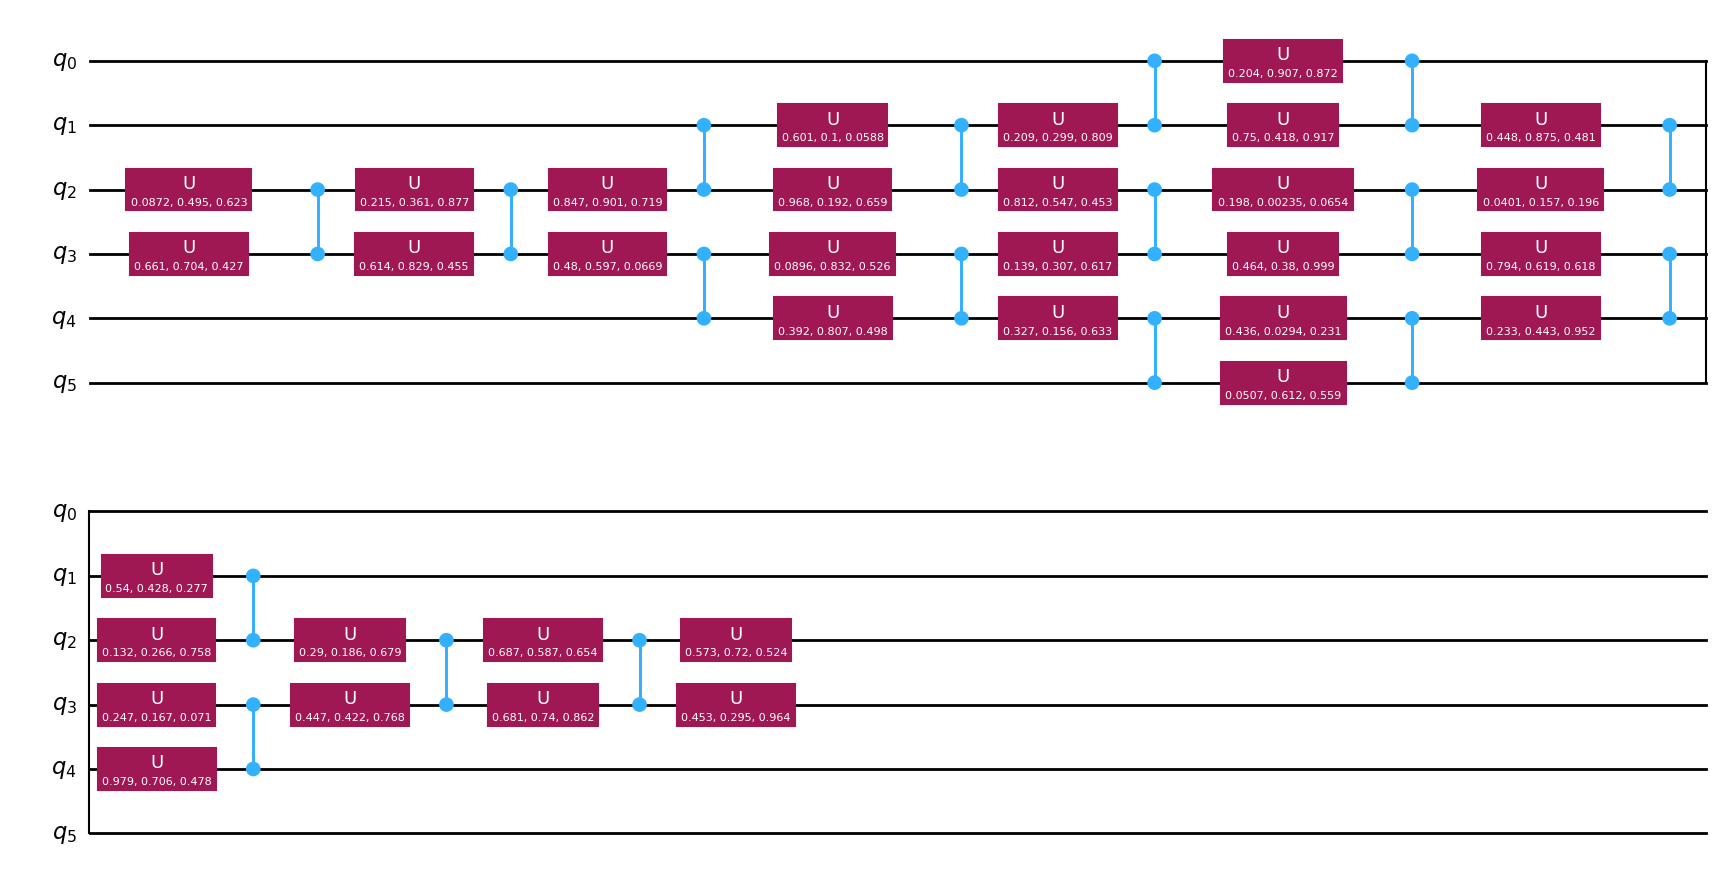

In [273]:
random_array = np.random.rand(102)
qc = block_6_circ(random_array)
#qc.draw('mpl')

In [275]:
random_array = np.random.rand(90)
qc = reduced_block_6_circ(random_array)
#qc.draw('mpl')

In [276]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

start_time = time.time()
new_params = []
block_devs = []
prec = 0.005
n_tries = 2
for i in range(1):
    params_init = np.random.rand(102)* 2 * PI
    res_min = find_alt_params_6(params_init, prec, n_tries)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
#print(new_params)

Elapsed time: 37.73545455932617 seconds


## Option 5. Here we assume a particular initial state

We replace block:
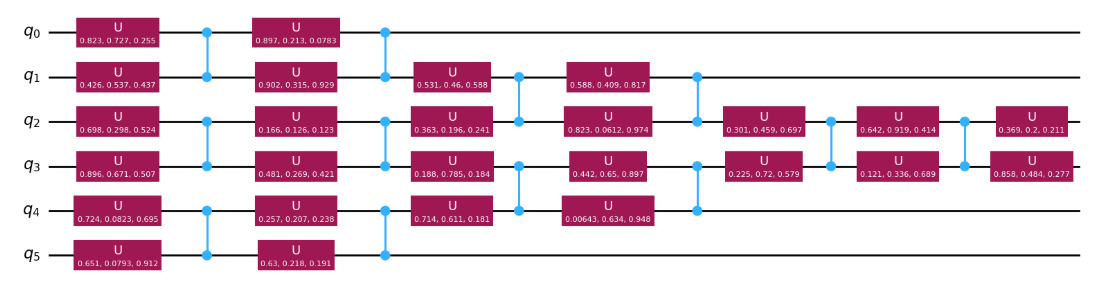

with the block:

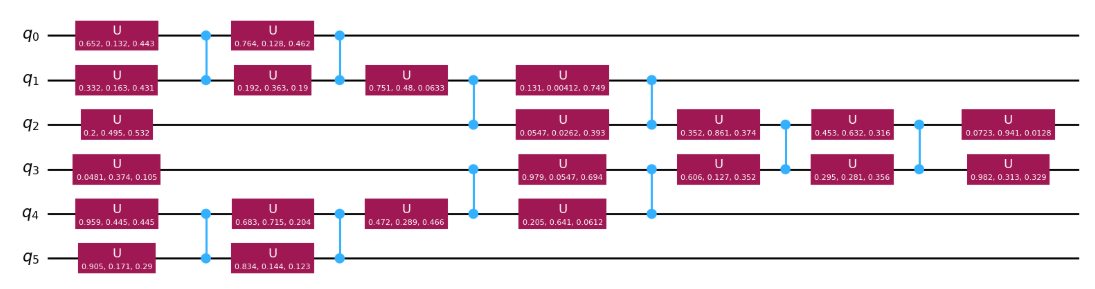

We optimize only the first row of the matrix, since the initial state is |0>^n. So, the rest of the matrix does not matter.

In previous cases I cannot use such an approach, since the state to which the matrix is applied is not |0>^n

In [415]:
def block_6_2_circ(par):
    q_2 = qiskit.QuantumCircuit(6)
    
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
  
    
    return q_2

def block_6_2(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    op = Operator(q_2)
    return op

def reduced_block_6_2_circ(par):

    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
        
    return q_2


def reduced_block_6_2(par):
    q_2 = qiskit.QuantumCircuit(6)

    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    
    op = Operator(q_2)
    return op


def double_q_diff_full(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el


def double_q_diff_partial(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    diff = 0 
    for i in range(0,64):
        for j in range(0,1):
            diff = diff + abs(mm.data[i][j]) * abs(mm.data[i][j])
    diff = np.sqrt(diff/64)
    return diff

def estim_func_6_2_full(params, init_circ):
    test_circ = reduced_block_6_2(params)
    est = double_q_diff_full(init_circ, test_circ)
    return est

def estim_func_6_2_partial(params, init_circ):
    test_circ = reduced_block_6_2(params)
    est = double_q_diff_partial(init_circ, test_circ)
    return est
    
def find_alt_params_6_full(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6_2(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_2_full,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

def find_alt_params_6_partial(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6_2(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_2_partial,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

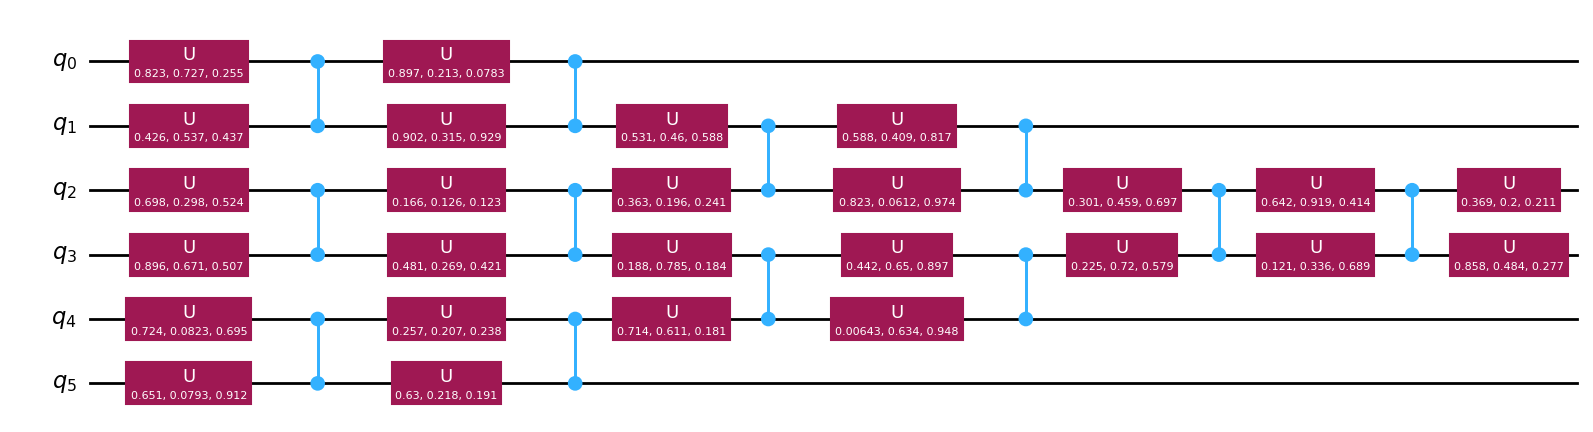

In [402]:
random_array = np.random.rand(78)
qc = block_6_2_circ(random_array)
qc.draw('mpl')

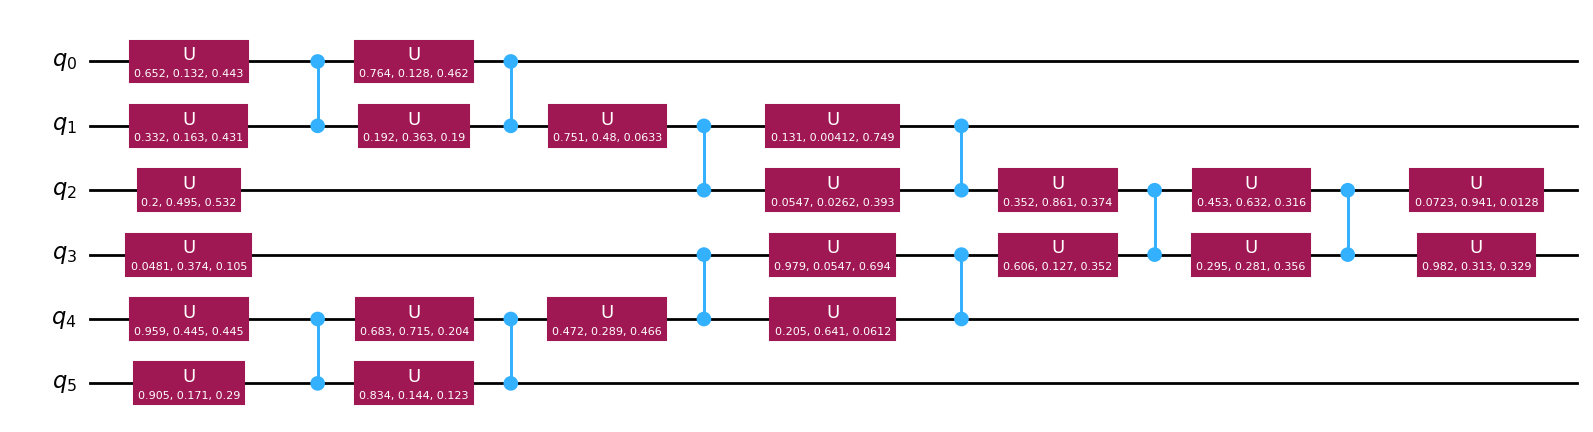

In [403]:
random_array = np.random.rand(66)
qc = reduced_block_6_2_circ(random_array)
qc.draw('mpl')

In [428]:
start_time = time.time()
new_params_full = []
block_devs_full = []
new_params_partial = []
block_devs_partial = []
prec = 0.005
n_tries = 2
for i in range(10):
    params_init = np.random.rand(78)* 2 * PI
    res_min_full = find_alt_params_6_full(params_init, prec, n_tries)
    res_min_partial = find_alt_params_6_partial(params_init, prec, n_tries)
    
    new_params_full.append(res_min_full.x)
    block_devs_full.append(res_min_full.fun)
    new_params_partial.append(res_min_partial.x)
    block_devs_partial.append(res_min_partial.fun)
    
    qc_init = block_6_2_circ(params_init)
    qc_init.measure_all()
    qc_red_full = reduced_block_6_2_circ(new_params_full[i])
    qc_red_full.measure_all()
    qc_red_partial = reduced_block_6_2_circ(new_params_partial[i])
    qc_red_partial.measure_all()
    
    qc_merged_t = transpile(qc_init, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_init = result.get_counts(qc_merged_t)
    
    qc_merged_t = transpile(qc_red_full, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_red_full = result.get_counts(qc_merged_t)
    
    qc_merged_t = transpile(qc_red_partial, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_red_partial = result.get_counts(qc_merged_t)
    diff_full = 0
    n = 0
    for k in counts_init.keys() & counts_red_full.keys():
        diff_full = diff_full + (counts_init[k] - counts_red_full[k]) * (counts_init[k] - counts_red_full[k])
        n = n + 1
    diff_full = np.sqrt(diff_full/n)
    
    print(n)
    print(diff_full)
    
    diff_partial = 0
    n = 0
    for k in counts_init.keys() & counts_red_partial.keys():
        diff_partial = diff_partial + (counts_init[k] - counts_red_partial[k]) * (counts_init[k] - counts_red_partial[k])
        n = n + 1
    diff_partial = np.sqrt(diff_partial/n)
    
    print(n)
    print(diff_partial)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

36
21.357408290541457
42
13.415520507091422
53
13.61879943729283
50
9.621850133939938
45
11.442610424782158
47
7.069563169266918
38
19.76972699010176
46
13.887748745473159
45
10.553567064162609
41
16.41608372536059
39
30.606267164481032
38
11.409829557285937
46
15.821009696795175
47
7.511693012556731
51
16.800443504883564
54
9.806460455570434
41
35.23890588263033
40
10.762202376837188
38
30.98981156852412
35
6.818043288635992
Elapsed time: 1108.8850824832916 seconds


In [422]:
print(block_devs_full)
print(block_devs_partial)

[0.0008883547867005635]
[0.02658270871137543]


In [424]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
simulator = AerSimulator()


In [425]:
diff_full = 0
n = 0
for k in counts_init.keys() & counts_red_full.keys():
    diff_full = diff_full + (counts_init[k] - counts_red_full[k]) * (counts_init[k] - counts_red_full[k])
    n = n + 1
diff_full = np.sqrt(diff_full/n)

print(n)
print(diff_full)

diff_partial = 0
n = 0
for k in counts_init.keys() & counts_red_partial.keys():
    diff_partial = diff_partial + (counts_init[k] - counts_red_partial[k]) * (counts_init[k] - counts_red_partial[k])
    n = n + 1
diff_partial = np.sqrt(diff_partial/n)

print(n)
print(diff_partial)

35
20.182028780929972
36
10.376254944182254
